## 7_Integrative enhancement of spectroscopic pipelines via GPCRmd-NMR - Adenosine A2A receptor

In [ ]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis.distances import distance_array
from scipy.signal import savgol_filter

In [25]:
# =============================
# Files
# =============================
PDB_FILE = "Computational_Data/dyn2733.pdb"
DCD_FILE = "Computational_Data/25722_trj_2375.dcd"
CS_FILE  = "Computational_Data/cs_dyn2375_25722.csv"

# =============================
# Time scaling
# =============================
delta_t_factor = 20   # convert frame time if needed

# =============================
# Target atoms
# =============================
TARGET_N_KEY = "N_243"

HBOND_PARTNERS = [
    ("O_239", 239, "O"),
    ("O_238", 238, "O")
]

# =============================
# Correlation threshold
# =============================
CORR_THRESHOLD = 0.7

In [26]:
def read_computational_CS_file(file_path):
    data_dict = {}
    with open(file_path, 'r') as file:
        csv_reader = csv.reader(file, delimiter=';')
        for row in csv_reader:
            if len(row) >= 2 and not row[0].startswith("resSeq"):
                key = f"{row[1]}_{row[0]}"
                values = [float(v.replace(',', '.')) for v in row[4:-1]]
                data_dict[key] = values
    return data_dict

cs_data = read_computational_CS_file(CS_FILE)
print("Loaded atoms:", len(cs_data))

Loaded atoms: 3652


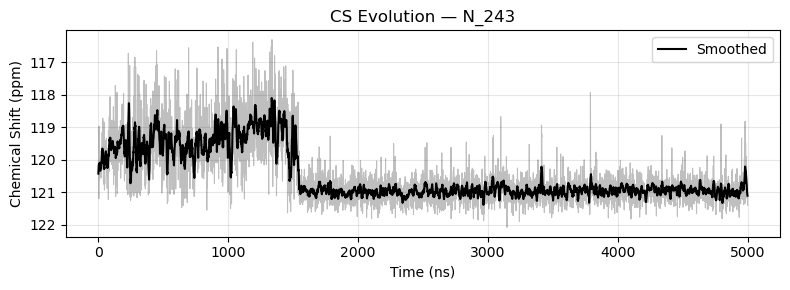

In [27]:
def plot_cs_evolution(atom_key):

    cs_values = np.array(cs_data[atom_key])
    time = np.arange(len(cs_values)) * delta_t_factor

    smooth_window = 21
    polyorder = 3
    if smooth_window % 2 == 0:
        smooth_window += 1

    cs_smooth = savgol_filter(cs_values, smooth_window, polyorder)

    plt.figure(figsize=(8,3))
    plt.plot(time/20, cs_values, alpha=0.25, linewidth=0.8, color="black")
    plt.plot(time/20, cs_smooth, linewidth=1.5, label="Smoothed", color="black")

    plt.xlabel("Time (ns)")
    plt.ylabel("Chemical Shift (ppm)")
    plt.title(f"CS Evolution — {atom_key}")
    plt.grid(alpha=0.3)
    plt.gca().invert_yaxis()
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_cs_evolution("N_243")

In [28]:
u = mda.Universe(PDB_FILE, DCD_FILE)
n_frames = len(u.trajectory)

In [29]:
# Select atoms
N243 = u.select_atoms("resid 243 and name N")[0]

partners = []
for label, resid, atomname in HBOND_PARTNERS:
    atom = u.select_atoms(f"resid {resid} and name {atomname}")[0]
    partners.append((label, atom))

# Prepare arrays
time = np.zeros(n_frames)
distances = {label: np.zeros(n_frames) for label, _ in partners}

# Compute
for i, ts in enumerate(u.trajectory):
    time[i] = ts.time * delta_t_factor

    for label, atom in partners:
        distances[label][i] = distance_array(
            N243.position,
            atom.position
        )[0][0]

print("Distance calculation done")

Distance calculation done


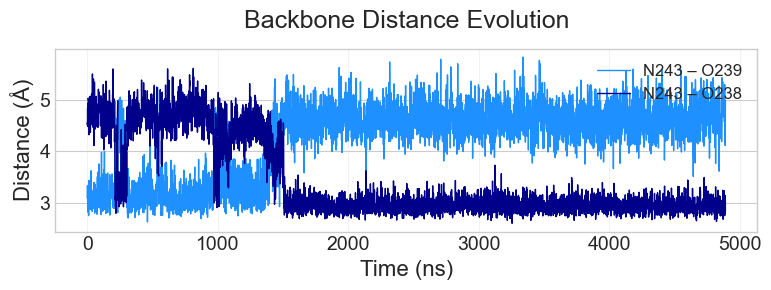

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")

plt.figure(figsize=(8, 3))

color_map = {
    "O_239": "dodgerblue",
    "O_238": "darkblue"
}

for label in distances:
    plt.plot(
        time,
        distances[label],
        linewidth=1,
        label=f"N243 – {label.replace('_', '')}",
        color=color_map.get(label, "blue")
    )

plt.xlabel("Time (ns)", fontsize=16)
plt.ylabel("Distance (Å)", fontsize=16)
plt.title("Backbone Distance Evolution", fontsize=18, pad=15)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Match original grid style (x only)
plt.grid(axis='x', alpha=0.25)

plt.legend(frameon=False, fontsize=12)

plt.tight_layout()

plt.savefig("distance_evolution_N243_O239_O238.png", dpi=600)

plt.show()